In [18]:
"""
Credit Card Fraud Detection Pipeline
Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
Place creditcard.csv in the same folder before running.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [20]:
# ──────────────────────────────────────────────
# 1. LOAD & EXPLORE
# ──────────────────────────────────────────────
print("=" * 60)
print("CREDIT CARD FRAUD DETECTION")
print("=" * 60)

df = pd.read_csv("creditcard.csv")
print(f"\nDataset shape : {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(df["Class"].value_counts())
print(f"Fraud %: {df['Class'].mean()*100:.4f}%")

CREDIT CARD FRAUD DETECTION

Dataset shape : (284807, 31)
Missing values: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud %: 0.1727%


In [21]:
# ──────────────────────────────────────────────
# 2. PREPROCESSING
# ──────────────────────────────────────────────

# Split features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Make copies to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test  = X_test.copy()

# Initialize scaler
scaler = StandardScaler()

# Scale only Amount and Time together (BEST PRACTICE)
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])
X_test[["Amount", "Time"]]  = scaler.transform(X_test[["Amount", "Time"]])

# Print sizes
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Train size: 227845 | Test size: 56962


In [22]:
# ──────────────────────────────────────────────
# 3. HANDLE CLASS IMBALANCE (Visualization Only)
# ──────────────────────────────────────────────

over  = SMOTE(sampling_strategy=0.1, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)

pipeline_resample = ImbPipeline([("over", over), ("under", under)])
X_res, y_res = pipeline_resample.fit_resample(X_train, y_train)

print("\nAfter resampling — Class distribution:")
unique, counts = np.unique(y_res, return_counts=True)
print({int(k): int(v) for k, v in zip(unique, counts)})


After resampling — Class distribution:
{0: 45490, 1: 22745}


In [23]:
# ──────────────────────────────────────────────
# 4. DEFINE CLASSIFIERS
# ──────────────────────────────────────────────
classifiers = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "KNN"                 : KNeighborsClassifier(n_neighbors=5),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM"                 : SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}


MODEL EVALUATION

────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99     56864
       Fraud       0.10      0.90      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.94      0.59     56962
weighted avg       1.00      0.99      0.99     56962

  ROC-AUC (test)     : 0.9679
  CV ROC-AUC (5-fold): 0.9804 ± 0.0123

────────────────────────────────────────
  KNN
────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00     56864
       Fraud       0.19      0.91      0.32        98

    accuracy                           0.99     56962
   macro avg       0.60      0.95      0.66     56962
weighted avg       1.00      0.99      1.00     56962

  ROC-AUC (test)     : 0.9525
  CV ROC-AUC (5-fold): 0.9413 ± 0.0

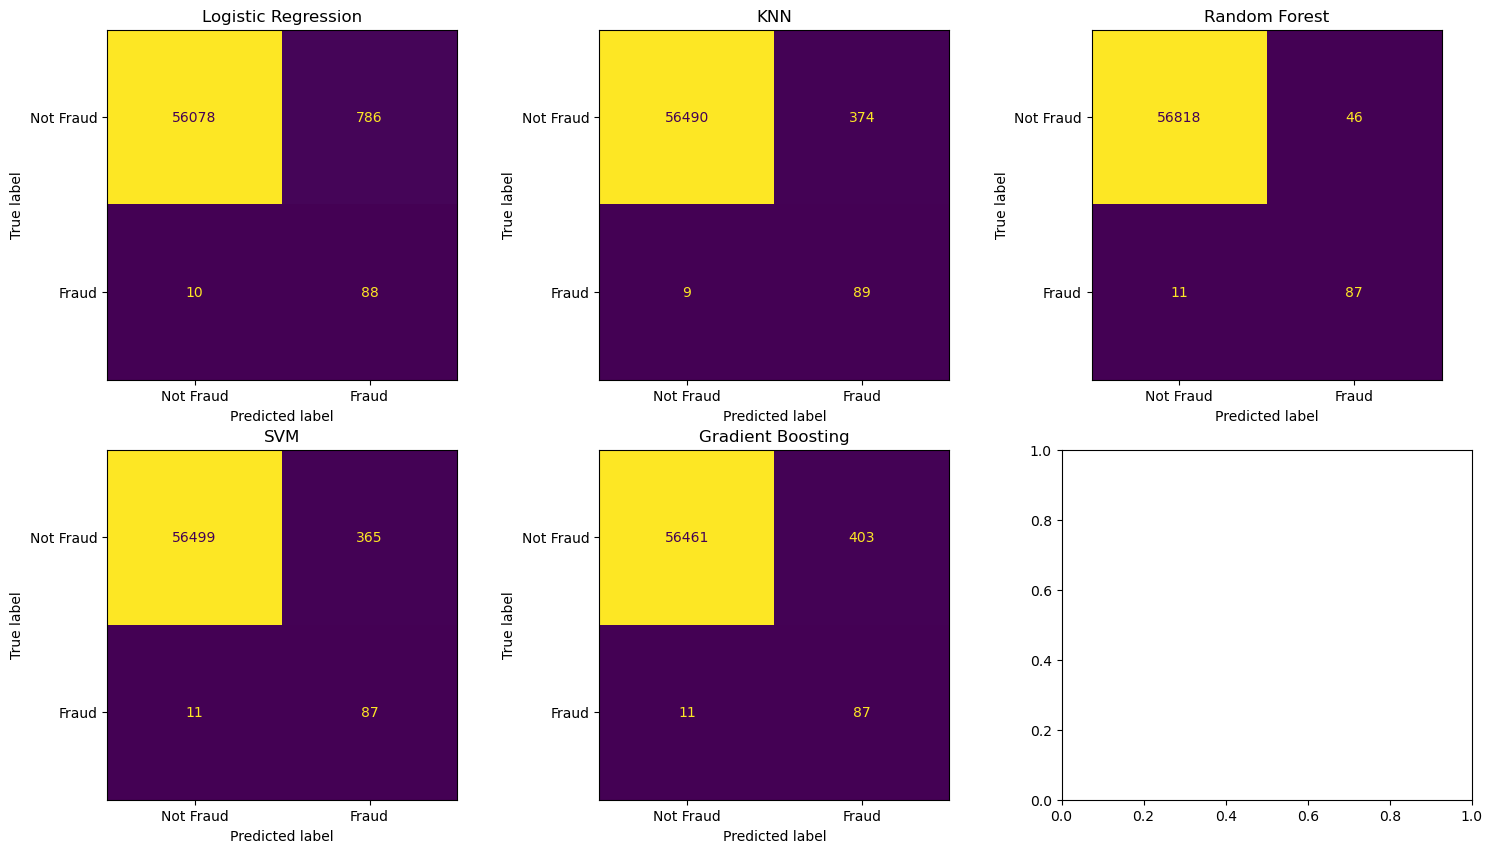

In [24]:
# ──────────────────────────────────────────────
# 5. TRAIN, EVALUATE, CROSS-VALIDATE 
# ──────────────────────────────────────────────

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 10))
axes_cm = axes_cm.flatten()

# Function to create pipeline
def make_pipeline(clf):
    return ImbPipeline([
        ("over", SMOTE(sampling_strategy=0.1, random_state=42)),
        ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
        ("model", clf),
    ])

for i, (name, clf) in enumerate(classifiers.items()):
    pipe = make_pipeline(clf)

    # Train on ORIGINAL data
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)

    # CV also on ORIGINAL data
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="roc_auc")

    results[name] = {
        "model"   : pipe,
        "roc_auc" : roc_auc,
        "cv_mean" : cv_scores.mean(),
        "cv_std"  : cv_scores.std(),
        "y_pred"  : y_pred,
        "y_proba" : y_proba,
    }

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))
    print(f"  ROC-AUC (test)     : {roc_auc:.4f}")
    print(f"  CV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
    disp.plot(ax=axes_cm[i], colorbar=False)
    axes_cm[i].set_title(name)

In [25]:
# ──────────────────────────────────────────────
# 6. HYBRID SOFT-VOTING ENSEMBLE 
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("HYBRID SOFT-VOTING ENSEMBLE")
print("=" * 60)

# Create pipelines again for ensemble
ensemble = VotingClassifier(
    estimators=[
        ("lr",  make_pipeline(LogisticRegression(max_iter=1000, random_state=42))),
        ("rf",  make_pipeline(RandomForestClassifier(n_estimators=100, random_state=42))),
        ("gb",  make_pipeline(GradientBoostingClassifier(n_estimators=100, random_state=42))),
        ("svm", make_pipeline(SVC(kernel="rbf", probability=True, random_state=42))),
        ("knn", make_pipeline(KNeighborsClassifier(n_neighbors=5))),
    ],
    voting="soft"
)

# Train on ORIGINAL data
ensemble.fit(X_train, y_train)

y_pred_ens  = ensemble.predict(X_test)
y_proba_ens = ensemble.predict_proba(X_test)[:, 1]

roc_ens = roc_auc_score(y_test, y_proba_ens)

# CV on ORIGINAL data
cv_ens = cross_val_score(ensemble, X_train, y_train, cv=skf, scoring="roc_auc")

results["Ensemble"] = {
    "model"  : ensemble,
    "roc_auc": roc_ens,
    "cv_mean": cv_ens.mean(),
    "cv_std" : cv_ens.std(),
    "y_pred" : y_pred_ens,
    "y_proba": y_proba_ens,
}

print(classification_report(y_test, y_pred_ens, target_names=["Not Fraud", "Fraud"]))
print(f"  ROC-AUC (test)     : {roc_ens:.4f}")
print(f"  CV ROC-AUC (5-fold): {cv_ens.mean():.4f} ± {cv_ens.std():.4f}")

# Confusion Matrix
cm_ens = confusion_matrix(y_test, y_pred_ens)
ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=["Not Fraud", "Fraud"]).plot(
    ax=axes_cm[5], colorbar=False
)
axes_cm[5].set_title("Hybrid Ensemble")

# ✅ FIX: use fig_cm explicitly instead of plt.*
fig_cm.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
fig_cm.tight_layout()
fig_cm.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close(fig_cm)

print("\n[Saved] confusion_matrices.png")


HYBRID SOFT-VOTING ENSEMBLE
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.33      0.90      0.48        98

    accuracy                           1.00     56962
   macro avg       0.66      0.95      0.74     56962
weighted avg       1.00      1.00      1.00     56962

  ROC-AUC (test)     : 0.9791
  CV ROC-AUC (5-fold): 0.9855 ± 0.0090

[Saved] confusion_matrices.png


In [26]:
# ──────────────────────────────────────────────
# 7. ROC CURVES
# ──────────────────────────────────────────────
plt.figure(figsize=(10, 7))
colors = ["steelblue", "darkorange", "green", "red", "purple", "black"]

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    lw = 2.5 if name == "Ensemble" else 1.5
    ls = "-" if name == "Ensemble" else "--"
    plt.plot(fpr, tpr, lw=lw, ls=ls, color=color,
             label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.close()
print("[Saved] roc_curves.png")

[Saved] roc_curves.png


In [27]:
# ──────────────────────────────────────────────
# 8. SUMMARY TABLE
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — ROC-AUC SCORES")
print("=" * 60)

summary = pd.DataFrame({
    "Model"       : list(results.keys()),
    "Test ROC-AUC": [r["roc_auc"] for r in results.values()],
    "CV Mean"     : [r["cv_mean"] for r in results.values()],
    "CV Std"      : [r["cv_std"]  for r in results.values()],
}).sort_values("Test ROC-AUC", ascending=False)

print(summary.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.barh(summary["Model"], summary["Test ROC-AUC"], color="steelblue", edgecolor="black")

# ✅ FIX: highlight best model (top one after sorting)
bars[0].set_color("darkorange")

plt.xlabel("ROC-AUC Score")
plt.title("Model Comparison — ROC-AUC", fontsize=13, fontweight="bold")
plt.xlim(0.8, 1.0)

for bar, val in zip(bars, summary["Test ROC-AUC"]):
    plt.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.close()

print("[Saved] model_comparison.png")
print("\nDone. All outputs saved.")


SUMMARY — ROC-AUC SCORES
              Model  Test ROC-AUC  CV Mean   CV Std
                SVM      0.980793 0.979129 0.009256
           Ensemble      0.979098 0.985491 0.008977
  Gradient Boosting      0.977841 0.976290 0.009856
      Random Forest      0.974568 0.983071 0.009997
Logistic Regression      0.967874 0.980416 0.012346
                KNN      0.952456 0.941271 0.016411
[Saved] model_comparison.png

Done. All outputs saved.
